In [ ]:
IMPORT REQUIRED LIBRARIES

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

**LOAD AND SAMPLE CIFAR10 DTASET**

In [ ]:
(x_train, y_train), (x_test, y_test)=tf.keras.datasets.cifar10.load_data()
from tensorflow.keras.applications import VGG16

print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
x_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)


In [ ]:
x_train,y_train=x_train[:100],y_train[:100]
x_test,y_test=x_test[:100],y_test[:100]

RESIZE IMAGES TO 224*224

In [ ]:
x_train = tf.image.resize(x_train, (224, 224))
x_test = tf.image.resize(x_test, (224, 224))

NORMALIZATION

In [ ]:
x_train=x_train/255.0
x_test=x_test/255.0

ONE HOT ENCODING

In [ ]:
y_train=to_categorical(y_train)
y_test=to_categorical(y_test)

LOAD PRETRAINED VGG16 WITHOUT TOP LAYERS

In [ ]:
base_model=VGG16(weights='imagenet',include_top=False,input_shape=(224,224,3))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


FREEZ BASEMODEL LAYERS(FEATURE EXTRACTION)

In [ ]:
for layer in base_model.layers:
  layer.trainable=False

ADD CUSTOM TOP LAYERS

In [ ]:
x=base_model.output
x=Flatten()(x)
x=Dense(512,activation='relu')(x)
x=Dropout(0.5)(x)
prediction=Dense(10, activation='softmax')(x)

CREATE FINAL MODEL

In [ ]:
model= Model(inputs=base_model.input,outputs=prediction)

COMPILE THE MODEL(FEATURE EXTRACTION PHASE)

In [ ]:
model.compile(optimizer=Adam(learning_rate=1e-4),loss='categorical_crossentropy',metrics=['accuracy'])

TRAIN THE MODEL(ONLY TOP LAYERS)

In [ ]:
model.compile(optimizer=Adam(learning_rate=1e-4),loss='categorical_crossentropy',metrics=['accuracy'])

fine-tue some convolutional layers

In [ ]:
for layer in base_model.layers[-4:]:
  layer.trainable=True

  compile again after unfreezing

In [ ]:
model.compile(optimizer=Adam(learning_rate=1e-5),loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
history_fine=model.fit(x_train,y_train,batch_size=32,epochs=5,validation_split=0.2)

Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 42s 11s/step - accuracy: 0.0250 - loss: 2.6627 - val_accuracy: 0.1000 - val_loss: 2.2858
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 272ms/step - accuracy: 0.0750 - loss: 2.4864 - val_accuracy: 0.2000 - val_loss: 2.2720
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 262ms/step - accuracy: 0.1625 - loss: 2.4374 - val_accuracy: 0.2000 - val_loss: 2.2968
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 274ms/step - accuracy: 0.1750 - loss: 2.3427 - val_accuracy: 0.2000 - val_loss: 2.3183
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 268ms/step - accuracy: 0.2125 - loss: 2.1469 - val_accuracy: 0.2000 - val_loss: 2.3375


EVALUATE ON TEST SET

In [ ]:
test_loss,test_acc=model.evaluate(x_test,y_test)
print("Test accuracy", test_acc)
print("Test loss", test_loss)

4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.1000 - loss: 2.4202
Test accuracy 0.10000000149011612
Test loss 2.420203924179077


PLOT ACCURACY GRAPH

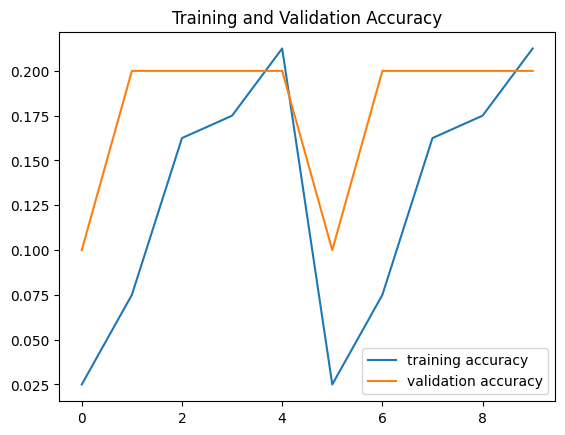

In [ ]:
plt.plot(history_fine.history['accuracy'],label='training accuracy')
plt.plot(history_fine.history['val_accuracy'],label='validation accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()